## 독립표번, 대응표본 t 검정
### 독립표본 t-검정
사례) 두 반(반 A, 반 B) 학생들의 평균 시험 점수가 같은지 검정하고자 한다. 각 반에서 무작위로 30명씩 추출하여 점수를 측정하였다.


In [1]:
import pandas as pd

df = pd.DataFrame({
    "A": [79, 81, 78, 84, 80, 85, 77, 82, 83, 79,
          80, 84, 82, 76, 85, 81, 79, 83, 78, 82,
          80, 86, 77, 84, 81, 79, 82, 80, 83, 78],
    "B": [83, 84, 82, 87, 86, 83, 80, 85, 86, 81,
          82, 88, 85, 80, 86, 84, 83, 86, 82, 85,
          84, 87, 81, 86, 85, 82, 84, 83, 86, 82]
})

#### (1) 통계적 가설 검정
- 귀무가설 : 두 반의 평균 점수는 같다.
- 대립가설 : 두 반의 평균 점수는 다르다. -> 양측 검정

#### (2) 유의 수준 결정
유의 수준 = 0.05
> 문제에서 주어지지 않으면 5%로 생각하기

#### (3) 양측검정, 등분산성 만족(기본값 alternative='two-sided', equal_var = True)
> 등분산성이란? <br>
> A와 B의 분산이 동일하다 (두 집단의 퍼진 정도가 비슷하다)

In [5]:
from scipy.stats import ttest_ind

ttest_ind(df['A'], df['B'], alternative='two-sided', equal_var = True)


TtestResult(statistic=np.float64(-4.8007799601793515), pvalue=np.float64(1.1500484590638477e-05), df=np.float64(58.0))

- 해석: 두 반 평균은 통계적으로 다르다

#### (5) 단측 검정 (<)
- 귀무 가설: 두 집단의 평균이 같다
- 대립 가설: B 반의 평균 점수가 더 높다

In [6]:
ttest_ind(df['A'], df['B'], alternative='less')

TtestResult(statistic=np.float64(-4.8007799601793515), pvalue=np.float64(5.7502422953192385e-06), df=np.float64(58.0))

- 해석: B 반의 평균 점수가 더 높다

#### (6) 비모수 대안
정규성 가정이 불만족이라면, 만휘트니 U 검정을 수행한다.(비모수 검정)

In [9]:
# 정규성 가정이 불만족이면, 만휘트니 U 검정을 수행한다.
from scipy import stats
stats.shapiro(df['A']), stats.shapiro(df['B']) # 둘다 0.05보다 큼 (모수)

(ShapiroResult(statistic=np.float64(0.9726612468120647), pvalue=np.float64(0.6142563392664292)),
 ShapiroResult(statistic=np.float64(0.9589498922840666), pvalue=np.float64(0.2911351980253418)))

In [11]:
# 만약 비모수면 아래처럼 만휘트니를 사용한다
stats.mannwhitneyu(df['A'], df['B'])

MannwhitneyuResult(statistic=np.float64(179.0), pvalue=np.float64(5.788791668999087e-05))

#### 등분산 검정
- 레빈의 검정을 활용하여 등분산 여부 확인 필요(H0: 두 집단은 등분산을 만족한다.)

In [12]:
stats.levene(df['A'], df['B'])

LeveneResult(statistic=np.float64(1.4262295081967222), pvalue=np.float64(0.2372420917554805))

- (해석) 유의수준 0.05에서 p-value가 0.237이므로 두 집단은 등분산을 만족함.

#### 1) 등분산을 만족한다면 독립표본 t-검정 수행

In [13]:
stats.ttest_ind(df['A'], df['B'])

TtestResult(statistic=np.float64(-4.8007799601793515), pvalue=np.float64(1.1500484590638477e-05), df=np.float64(58.0))

#### 2) 등분산을 만족하지 않는다면 Welch's t-검정 수행

In [14]:
stats.ttest_ind(df['A'], df['B'], equal_var = False)

TtestResult(statistic=np.float64(-4.8007799601793515), pvalue=np.float64(1.2253615450692508e-05), df=np.float64(55.7658623506532))

-> 해석 유의수준 0.05에서 p-value가 작으므로, 귀무 가설 기각 -> 두 반 평균은 통계적으로 다르다

### 대응표본 t-검정
사례) 같은 학생 24명을 대상으로 보강 수업 전/후 점수를 비교한다. 평균 향상이 있는지 검정하라.
(같은 대상을 두 번 측정하는 경우)

In [16]:
import pandas as pd

df_paired = pd.DataFrame({
    "before": [72, 75, 78, 70, 76, 79, 74, 77, 73, 75, 76, 72,
               74, 77, 71, 78, 73, 76, 75, 72, 74, 76, 73, 75],
    "after":  [74, 77, 80, 72, 78, 80, 76, 79, 74, 77, 78, 73,
               76, 79, 72, 80, 74, 78, 77, 73, 76, 78, 74, 77]
})

### (1) 통계적 가설 설정
- 귀무가설: 전후 평균 차이가 없다
- 대립가설: 전후 평균 차이가 있다 -> 양측검증

### (2) 유의 수준 결정
0.05

### (3) 양측 검정 (기본값 alternative='two-sided)

In [18]:
stats.ttest_rel(df_paired['after'], df_paired['before'])

TtestResult(statistic=np.float64(18.024959352627278), pvalue=np.float64(4.604089407815267e-15), df=np.int64(23))

(해석) p-value가 0.05보다 작으므로, 보강 수업 후 점수가 유의하게 변화하였다.

#### (4) 단측검정(>)
- 귀무가설: 전후 평균 차이가 없다
- 대립가설: 전후 평균이 증가하였다,  (<) 전후 평균이 감소하였다

In [23]:
print(stats.ttest_rel(df_paired['after'], df_paired['before'], alternative='less'),
stats.ttest_rel(df_paired['after'], df_paired['before'], alternative='greater'))

TtestResult(statistic=np.float64(18.024959352627278), pvalue=np.float64(0.9999999999999977), df=np.int64(23)) TtestResult(statistic=np.float64(18.024959352627278), pvalue=np.float64(2.3020447039076333e-15), df=np.int64(23))


(해석) 전후 평균이 증가하였다

#### (5) 비모수 대안
> 독립표본 t-검정 때는 비모수 여부를 볼 때, 표본 각각을 돌려서 판단했지만, <br>
> 대응표본 t-검정은 차이를 봐야 하기 때문에 두 표본 차이를 넣어준다

In [24]:
stats.shapiro(df_paired['after'] - df_paired['before'])

ShapiroResult(statistic=np.float64(0.5733448564576344), pvalue=np.float64(3.1562691788744337e-07))

(해석) 데이터는 정규분포를 따르지 않는다

정규성 가정이 불만족이면, 윌콕슨 부호순위 검정을 수행한다.


In [25]:
stats.wilcoxon(df_paired['after'], df_paired['before'])

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(7.117886553922734e-06))

(해석) 보강 수업 후 점수가 유의하게 변화하였다

## t-검정 정리
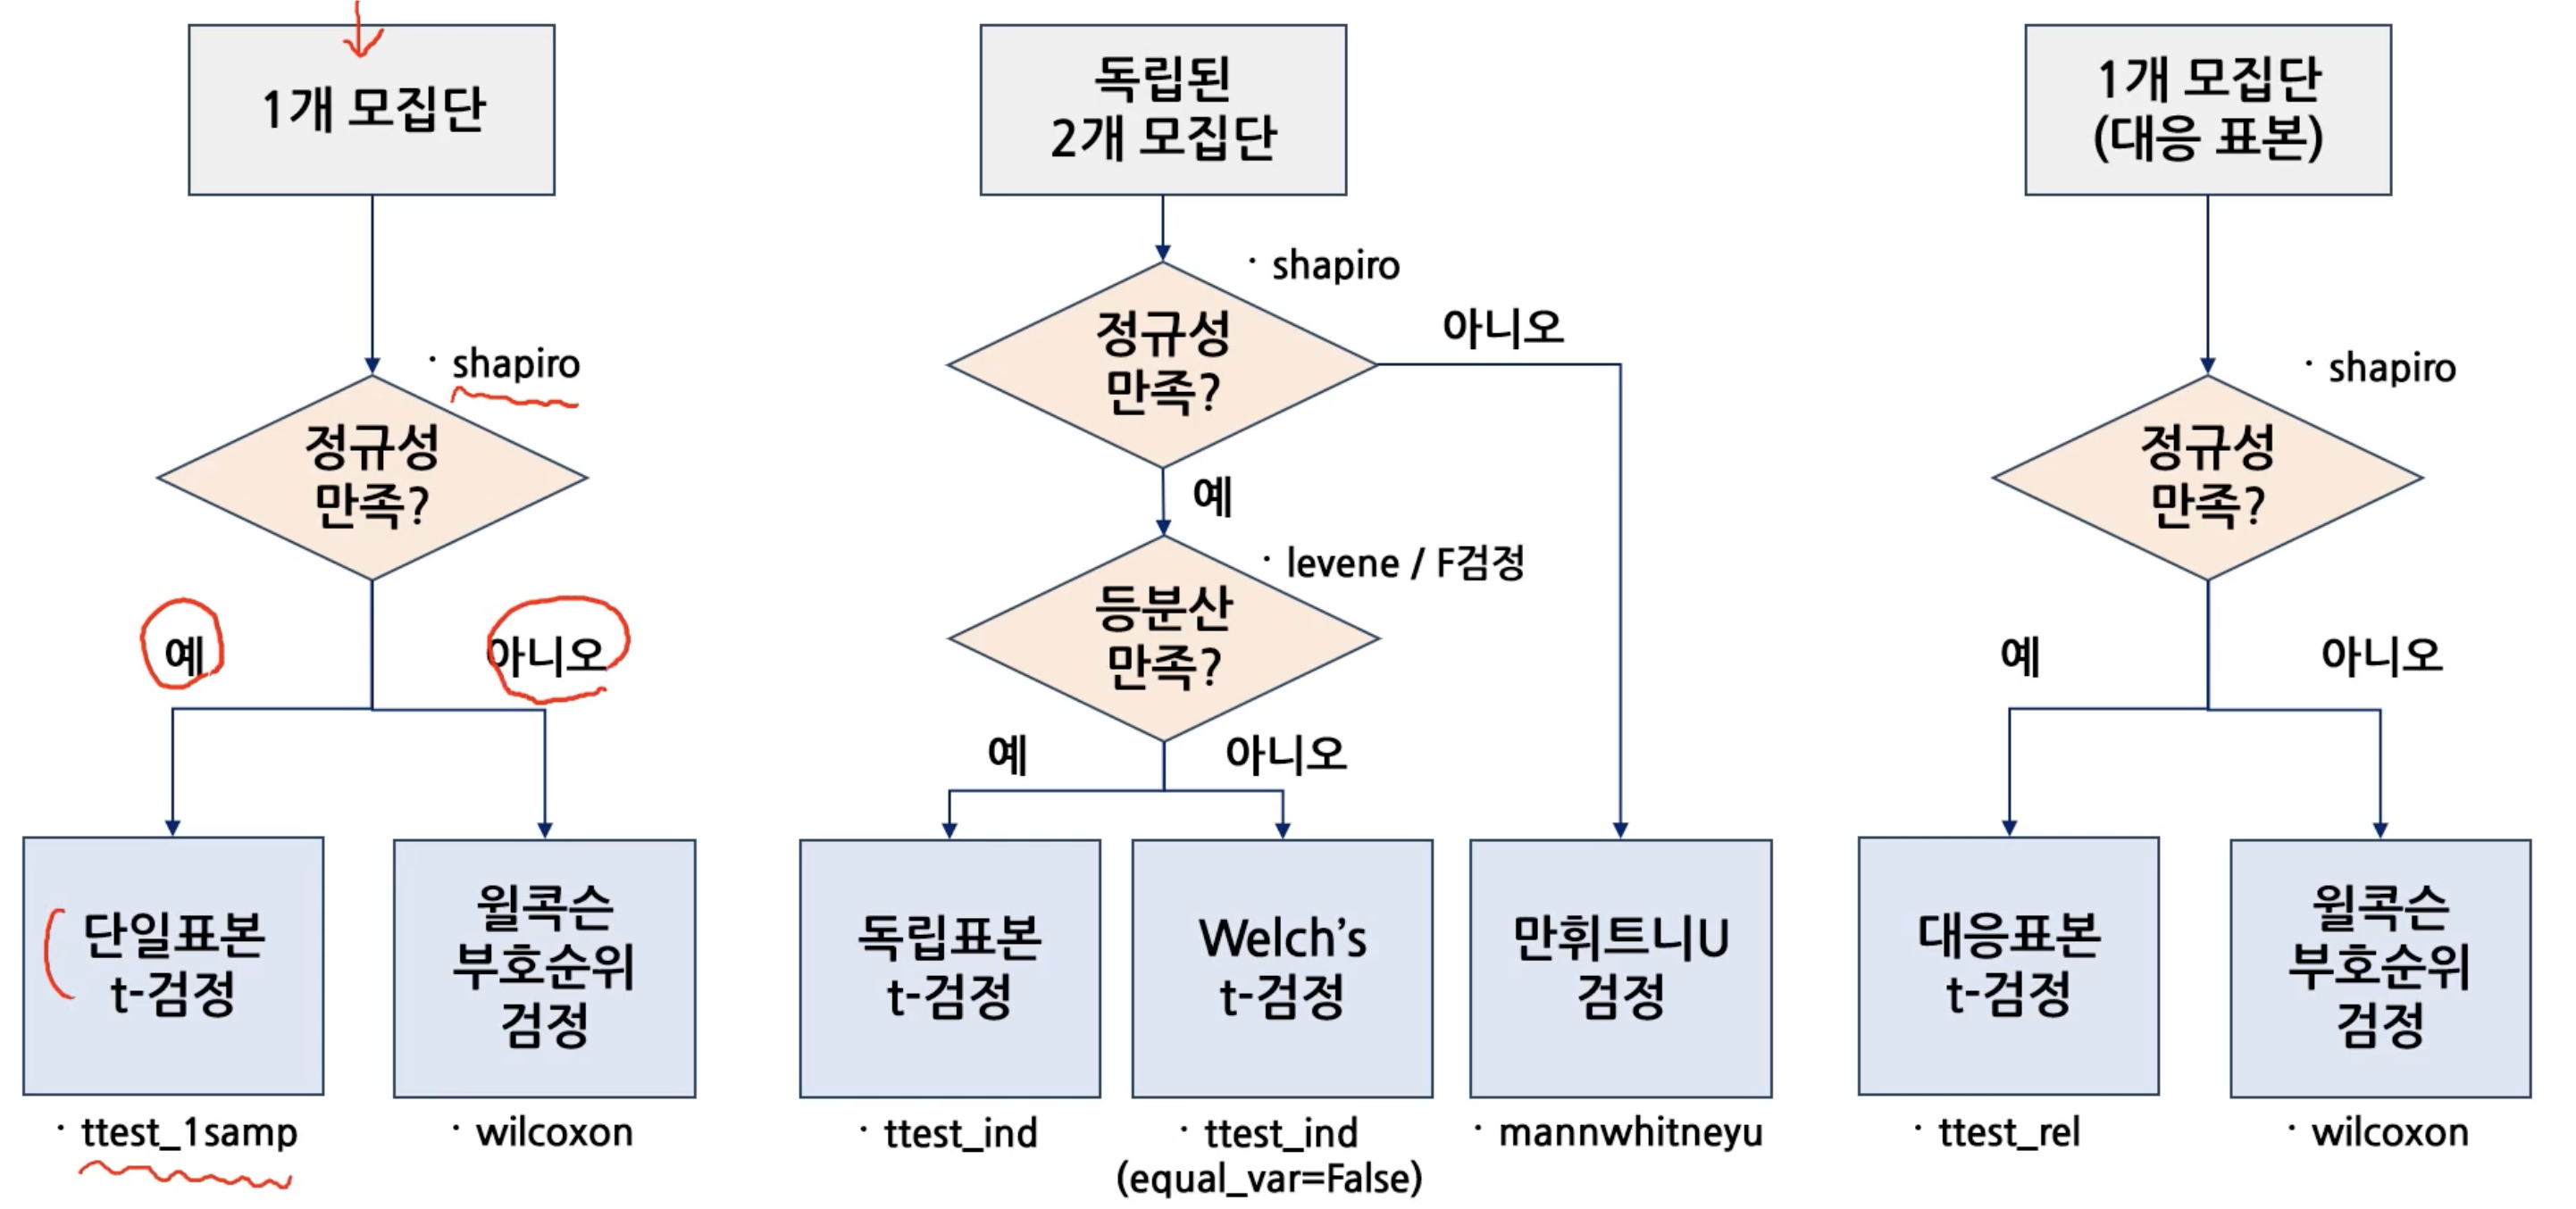